In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
df=pd.read_csv('merged_data.csv')
df.head(10)

,Date,Scrip,Open,High,Low,Close,Volume
0,2000-01-01,ACI,12.674539,13.774594,12.674539,13.631108,19850
1,2000-01-01,ALLTEX,4.700000,4.750000,4.700000,4.700000,17500
2,2000-01-01,AMBEEPHA,31.200000,32.000000,31.200000,31.600000,1150
3,2000-01-01,AMCL(PRAN),26.000000,27.000000,26.000000,26.525000,2500
4,2000-01-01,APEXFOODS,30.050000,30.500000,29.950000,30.175000,850
5,2000-01-01,APEXFOOT,6.201352,6.368287,6.201352,6.272906,300
6,2000-01-01,APEXSPINN,9.450000,9.450000,9.300000,9.425000,2600
7,2000-01-01,APEXTANRY,12.700000,12.950000,12.700000,12.750000,4100
8,2000-01-01,ARAMIT,30.333300,31.000000,30.266700,30.733300,32175
9,2000-01-01,ATLASBANG,38.355182,38.355182,38.355182,38.355182,593


In [24]:
df.isnull().sum()

Date      0
Scrip     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [25]:
# Duplicates check
df.duplicated().sum()

np.int64(0)

In [26]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [27]:
df.isnull().sum()


Date      0
Scrip     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [28]:
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window, min_periods=1).mean()
    avg_loss = pd.Series(loss).rolling(window=window, min_periods=1).mean()
    rs = avg_gain / (avg_loss + 1e-6)  # avoid division by zero
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = df.groupby('Scrip')['Close'].transform(compute_rsi)


In [29]:
df.head(5)

,Date,Scrip,Open,High,Low,Close,Volume,RSI
0,2000-01-01,ACI,12.674539,13.774594,12.674539,13.631108,19850,0.000000
1,2000-01-01,ALLTEX,4.700000,4.750000,4.700000,4.700000,17500,0.000000
2,2000-01-01,AMBEEPHA,31.200000,32.000000,31.200000,31.600000,1150,99.999727
3,2000-01-01,AMCL(PRAN),26.000000,27.000000,26.000000,26.525000,2500,82.027589
4,2000-01-01,APEXFOODS,30.050000,30.500000,29.950000,30.175000,850,69.124360


In [30]:
import pandas as pd

# Numerical columns select 
num_cols = df.select_dtypes(include='number').columns

# Aggregation: Mean and  Mode
agg_df = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Mode': df[num_cols].mode().iloc[0]  
})

# Display
agg_df


,Mean,Mode
Open,1.054704e+02,7.0
High,1.068120e+02,7.0
Low,1.040851e+02,6.9
Close,1.052271e+02,6.9
Volume,4.829822e+07,1.0
RSI,4.798531e+01,0.0


In [31]:
#Feature Engineering
# Price difference
df['Price_diff'] = df['Close'] - df['Open']

# Volatility (High - Low)
df['Volatility'] = df['High'] - df['Low']

# Moving Average (MA5)
df['MA5'] = df['Close'].rolling(window=5, min_periods=1).mean()


# Day of Week from Date
df['Date'] = pd.to_datetime(df['Date'])
# df['Day_of_Week'] = df['Date'].dt.dayofweek
df.head(5)

,Date,Scrip,Open,High,Low,Close,Volume,RSI,Price_diff,Volatility,MA5
0,2000-01-01,ACI,12.674539,13.774594,12.674539,13.631108,19850,0.000000,0.956569,1.100054,13.631108
1,2000-01-01,ALLTEX,4.700000,4.750000,4.700000,4.700000,17500,0.000000,0.000000,0.050000,9.165554
2,2000-01-01,AMBEEPHA,31.200000,32.000000,31.200000,31.600000,1150,99.999727,0.400000,0.800000,16.643703
3,2000-01-01,AMCL(PRAN),26.000000,27.000000,26.000000,26.525000,2500,82.027589,0.525000,1.000000,19.114027
4,2000-01-01,APEXFOODS,30.050000,30.500000,29.950000,30.175000,850,69.124360,0.125000,0.550000,21.326222


In [32]:
# Next-day price movement
df['Target'] = df.groupby('Scrip')['Close'].shift(-1) > df['Close']
df['Target'] = df['Target'].astype(int)
df.head(10)

,Date,Scrip,Open,High,Low,Close,Volume,RSI,Price_diff,Volatility,MA5,Target
0,2000-01-01,ACI,12.674539,13.774594,12.674539,13.631108,19850,0.000000,0.956569,1.100054,13.631108,0
1,2000-01-01,ALLTEX,4.700000,4.750000,4.700000,4.700000,17500,0.000000,0.000000,0.050000,9.165554,0
2,2000-01-01,AMBEEPHA,31.200000,32.000000,31.200000,31.600000,1150,99.999727,0.400000,0.800000,16.643703,0
3,2000-01-01,AMCL(PRAN),26.000000,27.000000,26.000000,26.525000,2500,82.027589,0.525000,1.000000,19.114027,0
4,2000-01-01,APEXFOODS,30.050000,30.500000,29.950000,30.175000,850,69.124360,0.125000,0.550000,21.326222,0
5,2000-01-01,APEXFOOT,6.201352,6.368287,6.201352,6.272906,300,95.337016,0.071554,0.166935,19.854581,0
6,2000-01-01,APEXSPINN,9.450000,9.450000,9.300000,9.425000,2600,50.274687,-0.025000,0.150000,20.799581,1
7,2000-01-01,APEXTANRY,12.700000,12.950000,12.700000,12.750000,4100,69.350592,0.050000,0.250000,17.029581,0
8,2000-01-01,ARAMIT,30.333300,31.000000,30.266700,30.733300,32175,48.158769,0.400000,0.733300,17.871241,0
9,2000-01-01,ATLASBANG,38.355182,38.355182,38.355182,38.355182,593,62.564984,0.000000,0.000000,19.507278,1


In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1 Feature Selection

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5','RSI','Price_diff','Volatility','MA5']
X = df[features]      
y = df['Target']      


# Stand





scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # Scale the features


X_scaled_df = pd.DataFrame(X_scaled, columns=features)  # use same column names as features


X_scaled_df.head(5)


,Open,High,Low,Close,Volume,MA5,RSI,Price_diff,Volatility,MA5
0,-0.096013,-0.096132,-0.094690,-0.094781,-0.069876,-0.206148,-2.513683,0.153439,-0.155003,-0.206148
1,-0.104264,-0.105457,-0.102950,-0.104022,-0.069879,-0.216198,-2.513683,0.031109,-0.255051,-0.216198
2,-0.076845,-0.077301,-0.075500,-0.076187,-0.069903,-0.199367,2.724745,0.082263,-0.183592,-0.199367
3,-0.082225,-0.082467,-0.080886,-0.081439,-0.069901,-0.193808,1.783285,0.098249,-0.164536,-0.193808
4,-0.078035,-0.078851,-0.076795,-0.077662,-0.069903,-0.188829,1.107357,0.047095,-0.207411,-0.188829


In [46]:
from sklearn.preprocessing import MinMaxScaler

scalerN = MinMaxScaler()
x_Max_min_scaled=scalerN.fit_transform(X)

x_Max_min_scaled_df = pd.DataFrame(x_Max_min_scaled, columns=features)
 # use same column names as features


x_Max_min_scaled_df.head(5)


,Open,High,Low,Close,Volume,MA5,RSI,Price_diff,Volatility,MA5
0,0.000012,0.000013,0.000013,0.000013,3.539644e-07,0.000055,0.000000,0.477028,0.001237,0.000055
1,0.000005,0.000005,0.000005,0.000005,3.120593e-07,0.000033,0.000000,0.476801,0.000992,0.000033
2,0.000030,0.000031,0.000030,0.000030,2.050675e-08,0.000069,0.999998,0.476896,0.001167,0.000069
3,0.000025,0.000026,0.000025,0.000026,4.457990e-08,0.000081,0.820276,0.476926,0.001214,0.000081
4,0.000029,0.000029,0.000029,0.000029,1.515717e-08,0.000092,0.691244,0.476831,0.001109,0.000092


In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)



In [35]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (967099, 10)
X_test shape: (414472, 10)
y_train shape: (967099,)
y_test shape: (414472,)


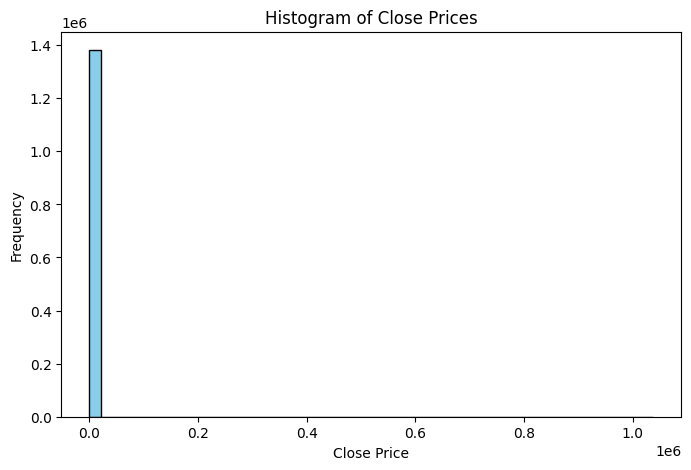

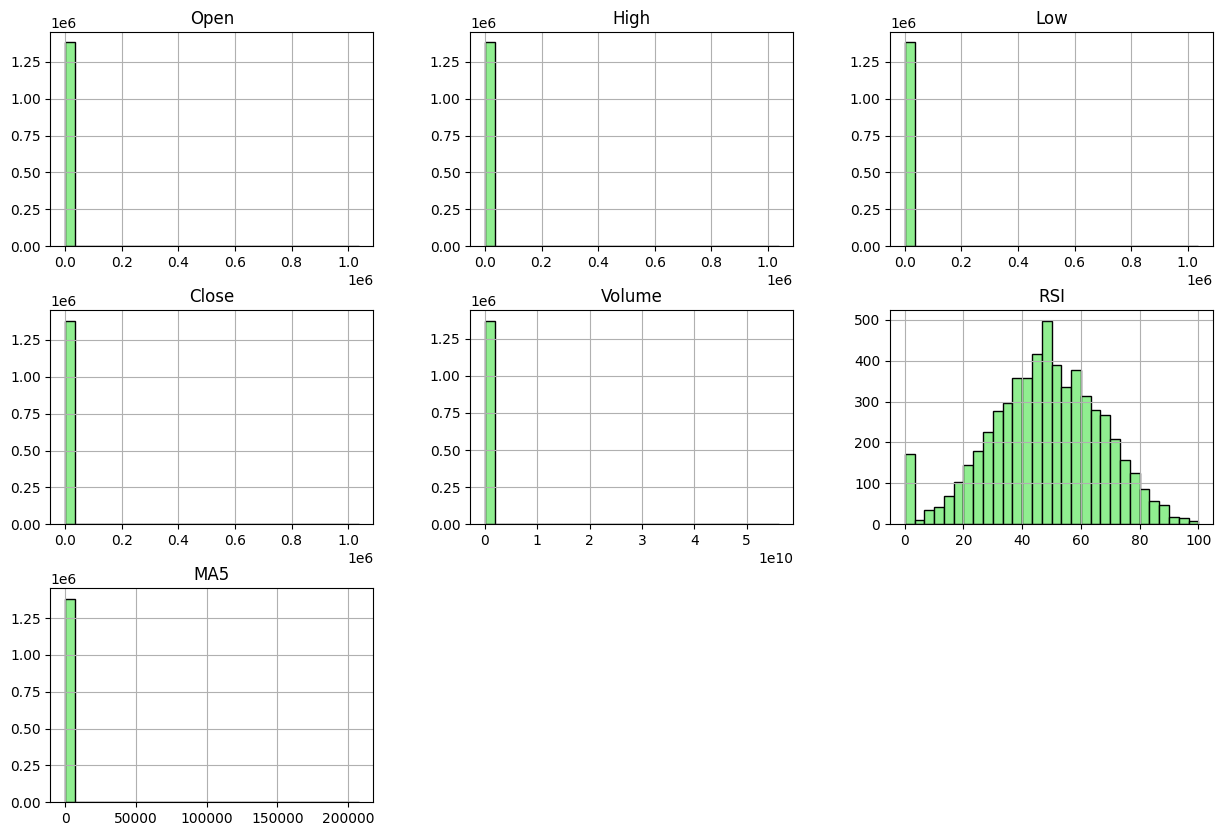

In [36]:
import matplotlib.pyplot as plt

# Example: Histogram of 'Close' prices
plt.figure(figsize=(8,5))
plt.hist(df['Close'], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of Close Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

# Optional: Histogram for multiple numerical columns
numerical_cols = ['Open','High','Low','Close','Volume','RSI','MA5']
df[numerical_cols].hist(bins=30, figsize=(15,10), color='lightgreen', edgecolor='black')
plt.show()


In [37]:
corr_matrix = df.select_dtypes(include='number').corr()
corr_matrix


,Open,High,Low,Close,Volume,RSI,Price_diff,Volatility,MA5,Target
Open,1.000000,0.999967,0.999965,0.999967,0.229293,0.009461,-0.016259,0.232177,0.453626,0.009794
High,0.999967,1.000000,0.999944,0.999974,0.230603,0.012591,-0.011279,0.237140,0.453740,0.010011
Low,0.999965,0.999944,1.000000,0.999978,0.228502,0.009450,-0.010562,0.226866,0.453571,0.009695
Close,0.999967,0.999974,0.999978,1.000000,0.229751,0.012801,-0.008169,0.231645,0.453640,0.009886
Volume,0.229293,0.230603,0.228502,0.229751,1.000000,0.011290,0.053854,0.246815,0.139464,0.019872
RSI,0.009461,0.012591,0.009450,0.012801,0.011290,1.000000,0.008927,0.008677,0.001304,-0.000593
Price_diff,-0.016259,-0.011279,-0.010562,-0.008169,0.053854,0.008927,1.000000,-0.068599,-0.003882,0.011200
Volatility,0.232177,0.237140,0.226866,0.231645,0.246815,0.008677,-0.068599,1.000000,0.120838,0.031424
MA5,0.453626,0.453740,0.453571,0.453640,0.139464,0.001304,-0.003882,0.120838,1.000000,-0.003019
Target,0.009794,0.010011,0.009695,0.009886,0.019872,-0.000593,0.011200,0.031424,-0.003019,1.000000


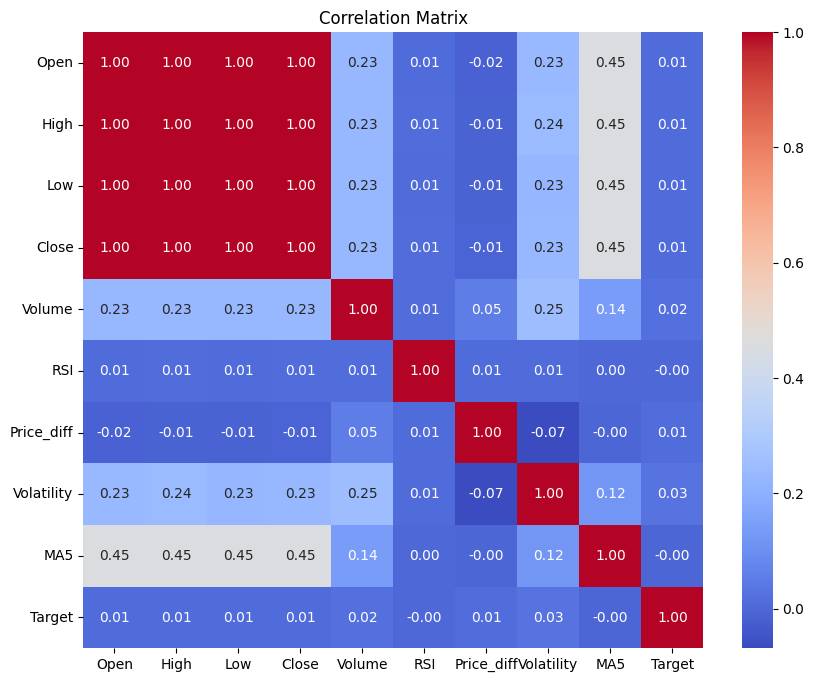

In [40]:
import seaborn as sns

numeric_corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
